In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from google.colab import files
uploaded = files.upload()

Saving student_dropout_200k.csv to student_dropout_200k (1).csv


In [6]:
df = pd.read_csv('student_dropout_200k.csv')

In [ ]:
df.head()

,id_assessment,id_student,date_submitted,is_banked,score,code_module,code_presentation,assessment_type,date,weight,...,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration,total_clicks
0,1752,11391,18,0,78.0,AAA,2013J,TMA,19.0,10.0,...,HE Qualification,90-100%,55<=,0,240,N,Pass,-159.0,0.0,934.0
1,1752,28400,22,0,70.0,AAA,2013J,TMA,19.0,10.0,...,HE Qualification,20-30%,35-55,0,60,N,Pass,-53.0,0.0,1435.0
2,1752,31604,17,0,72.0,AAA,2013J,TMA,19.0,10.0,...,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,-52.0,0.0,2158.0
3,1752,32885,26,0,69.0,AAA,2013J,TMA,19.0,10.0,...,Lower Than A Level,50-60%,0-35,0,60,N,Pass,-176.0,0.0,1034.0
4,1752,38053,19,0,79.0,AAA,2013J,TMA,19.0,10.0,...,A Level or Equivalent,80-90%,35-55,0,60,N,Pass,-110.0,0.0,2445.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id_assessment         200000 non-null  int64  
 1   id_student            200000 non-null  int64  
 2   date_submitted        200000 non-null  int64  
 3   is_banked             200000 non-null  int64  
 4   score                 200000 non-null  float64
 5   code_module           200000 non-null  object 
 6   code_presentation     200000 non-null  object 
 7   assessment_type       200000 non-null  object 
 8   date                  200000 non-null  float64
 9   weight                200000 non-null  float64
 10  gender                200000 non-null  object 
 11  region                200000 non-null  object 
 12  highest_education     200000 non-null  object 
 13  imd_band              200000 non-null  object 
 14  age_band              200000 non-null  object 
 15  

In [ ]:
df.isnull().sum()

,0
id_assessment,0
id_student,0
date_submitted,0
is_banked,0
score,0
code_module,0
code_presentation,0
assessment_type,0
date,0
weight,0


In [ ]:
df.duplicated().sum()

np.int64(26088)

In [ ]:
df.describe(

)

,id_assessment,id_student,date_submitted,is_banked,score,date,weight,num_of_prev_attempts,studied_credits,date_registration,date_unregistration,total_clicks
count,200000.000000,2.000000e+05,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,26546.516680,7.049342e+05,115.926475,0.010780,75.729715,128.457135,12.728065,0.145265,76.814325,-65.926130,10.410565,1967.501595
std,8831.094497,5.528688e+05,71.451964,0.103266,18.930647,79.157837,17.839941,0.446200,37.319195,46.995882,40.163397,2028.420559
min,1752.000000,6.516000e+03,-11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,30.000000,-311.000000,-196.000000,0.000000
25%,15022.000000,5.042310e+05,51.000000,0.000000,65.000000,53.000000,0.000000,0.000000,60.000000,-94.000000,0.000000,583.000000
50%,25359.000000,5.851280e+05,116.000000,0.000000,80.000000,124.000000,10.000000,0.000000,60.000000,-53.000000,0.000000,1290.000000
75%,34883.000000,6.344610e+05,173.000000,0.000000,90.000000,208.000000,18.000000,0.000000,90.000000,-29.000000,0.000000,2700.000000
max,37443.000000,2.698588e+06,608.000000,1.000000,100.000000,261.000000,100.000000,6.000000,630.000000,167.000000,444.000000,24139.000000


In [ ]:
print(f"Number of duplicated rows before dropping: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Number of duplicated rows after dropping: {df.duplicated().sum()}")

Number of duplicated rows before dropping: 26088
Number of duplicated rows after dropping: 0


In [ ]:
categorical_cols = ['code_module', 'code_presentation', 'assessment_type', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability', 'final_result']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 173912 entries, 0 to 173911
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   id_assessment         173912 non-null  int64   
 1   id_student            173912 non-null  int64   
 2   date_submitted        173912 non-null  int64   
 3   is_banked             173912 non-null  int64   
 4   score                 173912 non-null  float64 
 5   code_module           173912 non-null  category
 6   code_presentation     173912 non-null  category
 7   assessment_type       173912 non-null  category
 8   date                  173912 non-null  float64 
 9   weight                173912 non-null  float64 
 10  gender                173912 non-null  category
 11  region                173912 non-null  category
 12  highest_education     173912 non-null  category
 13  imd_band              173912 non-null  category
 14  age_band              173912 non-null  ca

In [ ]:
df.shape

(173912, 22)

In [ ]:
df['time_to_submit'] = df['date_submitted'] - df['date']

df['registration_days_before_start'] = df['date_registration'].apply(lambda x: abs(x) if x < 0 else 0)

df['clicks_per_day_active'] = df['total_clicks'] / (df['date'] + 1)

df['assessment_late'] = (df['time_to_submit'] > 0).astype(int)
df['assessment_early'] = (df['time_to_submit'] < 0).astype(int)


print("New features created. Displaying head with new features:")
display(df.head())

print("\nUpdated DataFrame info with new features:")
df.info()

New features created. Displaying head with new features:


,id_assessment,id_student,date_submitted,is_banked,score,code_module,code_presentation,assessment_type,date,weight,...,disability,final_result,date_registration,date_unregistration,total_clicks,time_to_submit,registration_days_before_start,clicks_per_day_active,assessment_late,assessment_early
0,1752,11391,18,0,78.0,AAA,2013J,TMA,19.0,10.0,...,N,Pass,-159.0,0.0,934.0,-1.0,159.0,46.70,0,1
1,1752,28400,22,0,70.0,AAA,2013J,TMA,19.0,10.0,...,N,Pass,-53.0,0.0,1435.0,3.0,53.0,71.75,1,0
2,1752,31604,17,0,72.0,AAA,2013J,TMA,19.0,10.0,...,N,Pass,-52.0,0.0,2158.0,-2.0,52.0,107.90,0,1
3,1752,32885,26,0,69.0,AAA,2013J,TMA,19.0,10.0,...,N,Pass,-176.0,0.0,1034.0,7.0,176.0,51.70,1,0
4,1752,38053,19,0,79.0,AAA,2013J,TMA,19.0,10.0,...,N,Pass,-110.0,0.0,2445.0,0.0,110.0,122.25,0,0



Updated DataFrame info with new features:
<class 'pandas.core.frame.DataFrame'>
Index: 173912 entries, 0 to 173911
Data columns (total 27 columns):
 #   Column                          Non-Null Count   Dtype   
---  ------                          --------------   -----   
 0   id_assessment                   173912 non-null  int64   
 1   id_student                      173912 non-null  int64   
 2   date_submitted                  173912 non-null  int64   
 3   is_banked                       173912 non-null  int64   
 4   score                           173912 non-null  float64 
 5   code_module                     173912 non-null  category
 6   code_presentation               173912 non-null  category
 7   assessment_type                 173912 non-null  category
 8   date                            173912 non-null  float64 
 9   weight                          173912 non-null  float64 
 10  gender                          173912 non-null  category
 11  region                     

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['final_result_encoded'] = le.fit_transform(df['final_result'])

print("Original 'final_result' unique values:", df['final_result'].unique())
print("Encoded 'final_result_encoded' unique values:", df['final_result_encoded'].unique())
print("Mapping of 'final_result':", list(le.classes_))
n
df.drop('final_result', axis=1, inplace=True)

display(df.head())

Original 'final_result' unique values: ['Pass', 'Withdrawn', 'Fail', 'Distinction']
Categories (4, object): ['Distinction', 'Fail', 'Pass', 'Withdrawn']
Encoded 'final_result_encoded' unique values: [2 3 1 0]
Mapping of 'final_result': ['Distinction', 'Fail', 'Pass', 'Withdrawn']


,id_assessment,id_student,date_submitted,is_banked,score,code_module,code_presentation,assessment_type,date,weight,...,disability,date_registration,date_unregistration,total_clicks,time_to_submit,registration_days_before_start,clicks_per_day_active,assessment_late,assessment_early,final_result_encoded
0,1752,11391,18,0,78.0,AAA,2013J,TMA,19.0,10.0,...,N,-159.0,0.0,934.0,-1.0,159.0,46.70,0,1,2
1,1752,28400,22,0,70.0,AAA,2013J,TMA,19.0,10.0,...,N,-53.0,0.0,1435.0,3.0,53.0,71.75,1,0,2
2,1752,31604,17,0,72.0,AAA,2013J,TMA,19.0,10.0,...,N,-52.0,0.0,2158.0,-2.0,52.0,107.90,0,1,2
3,1752,32885,26,0,69.0,AAA,2013J,TMA,19.0,10.0,...,N,-176.0,0.0,1034.0,7.0,176.0,51.70,1,0,2
4,1752,38053,19,0,79.0,AAA,2013J,TMA,19.0,10.0,...,N,-110.0,0.0,2445.0,0.0,110.0,122.25,0,0,2


In [ ]:
categorical_cols_for_ohe = [col for col in df.select_dtypes(include='category').columns if col != 'final_result']

df = pd.get_dummies(df, columns=categorical_cols_for_ohe, drop_first=True)

for col in df.select_dtypes(include='bool').columns:
    df[col] = df[col].astype(int)

print("DataFrame after One-Hot Encoding and boolean to int conversion:")
display(df.head())
print("\nUpdated DataFrame info after encoding:")
df.info()

DataFrame after One-Hot Encoding and boolean to int conversion:


,id_assessment,id_student,date_submitted,is_banked,score,date,weight,num_of_prev_attempts,studied_credits,date_registration,...,imd_band_30-40%,imd_band_40-50%,imd_band_50-60%,imd_band_60-70%,imd_band_70-80%,imd_band_80-90%,imd_band_90-100%,age_band_35-55,age_band_55<=,disability_Y
0,1752,11391,18,0,78.0,19.0,10.0,0,240,-159.0,...,0,0,0,0,0,0,1,0,1,0
1,1752,28400,22,0,70.0,19.0,10.0,0,60,-53.0,...,0,0,0,0,0,0,0,1,0,0
2,1752,31604,17,0,72.0,19.0,10.0,0,60,-52.0,...,0,0,1,0,0,0,0,1,0,0
3,1752,32885,26,0,69.0,19.0,10.0,0,60,-176.0,...,0,0,1,0,0,0,0,0,0,0
4,1752,38053,19,0,79.0,19.0,10.0,0,60,-110.0,...,0,0,0,0,0,1,0,1,0,0



Updated DataFrame info after encoding:
<class 'pandas.core.frame.DataFrame'>
Index: 173912 entries, 0 to 173911
Data columns (total 59 columns):
 #   Column                                         Non-Null Count   Dtype  
---  ------                                         --------------   -----  
 0   id_assessment                                  173912 non-null  int64  
 1   id_student                                     173912 non-null  int64  
 2   date_submitted                                 173912 non-null  int64  
 3   is_banked                                      173912 non-null  int64  
 4   score                                          173912 non-null  float64
 5   date                                           173912 non-null  float64
 6   weight                                         173912 non-null  float64
 7   num_of_prev_attempts                           173912 non-null  int64  
 8   studied_credits                                173912 non-null  int64  
 9   da

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('final_result_encoded', axis=1)
y = df['final_result_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\ny_train distribution:\n", y_train.value_counts(normalize=True))
print("\ny_test distribution:\n", y_test.value_counts(normalize=True))

X_train shape: (139129, 58)
X_test shape: (34783, 58)
y_train shape: (139129,)
y_test shape: (34783,)

y_train distribution:
 final_result_encoded
2    0.609621
1    0.163683
0    0.151399
3    0.075297
Name: proportion, dtype: float64

y_test distribution:
 final_result_encoded
2    0.609637
1    0.163672
0    0.151396
3    0.075295
Name: proportion, dtype: float64


In [ ]:
columns_to_drop = [
    'id_assessment', 'id_student',
    'date_submitted', 'date', 'date_registration', 'date_unregistration',
    'code_module', 'code_presentation', 'assessment_type', 'gender', 'region',
    'highest_education', 'imd_band', 'age_band', 'disability'
]

columns_to_drop = [col for col in columns_to_drop if col in df.columns]

df.drop(columns=columns_to_drop, inplace=True)

print("DataFrame after dropping unnecessary columns:")
display(df.head())
print("\nUpdated DataFrame info:")
df.info()

DataFrame after dropping unnecessary columns:


,is_banked,score,weight,num_of_prev_attempts,studied_credits,total_clicks,time_to_submit,registration_days_before_start,clicks_per_day_active,assessment_late,...,imd_band_30-40%,imd_band_40-50%,imd_band_50-60%,imd_band_60-70%,imd_band_70-80%,imd_band_80-90%,imd_band_90-100%,age_band_35-55,age_band_55<=,disability_Y
0,0,78.0,10.0,0,240,934.0,-1.0,159.0,46.70,0,...,0,0,0,0,0,0,1,0,1,0
1,0,70.0,10.0,0,60,1435.0,3.0,53.0,71.75,1,...,0,0,0,0,0,0,0,1,0,0
2,0,72.0,10.0,0,60,2158.0,-2.0,52.0,107.90,0,...,0,0,1,0,0,0,0,1,0,0
3,0,69.0,10.0,0,60,1034.0,7.0,176.0,51.70,1,...,0,0,1,0,0,0,0,0,0,0
4,0,79.0,10.0,0,60,2445.0,0.0,110.0,122.25,0,...,0,0,0,0,0,1,0,1,0,0



Updated DataFrame info:
<class 'pandas.core.frame.DataFrame'>
Index: 173912 entries, 0 to 173911
Data columns (total 53 columns):
 #   Column                                         Non-Null Count   Dtype  
---  ------                                         --------------   -----  
 0   is_banked                                      173912 non-null  int64  
 1   score                                          173912 non-null  float64
 2   weight                                         173912 non-null  float64
 3   num_of_prev_attempts                           173912 non-null  int64  
 4   studied_credits                                173912 non-null  int64  
 5   total_clicks                                   173912 non-null  float64
 6   time_to_submit                                 173912 non-null  float64
 7   registration_days_before_start                 173912 non-null  float64
 8   clicks_per_day_active                          173912 non-null  float64
 9   assessment_late  

Training RandomForestClassifier...
Training complete.

Model Evaluation:
Accuracy: 0.8403242963516661

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.59      0.72      5266
           1       0.88      0.51      0.65      5693
           2       0.81      0.97      0.88     21205
           3       1.00      0.99      1.00      2619

    accuracy                           0.84     34783
   macro avg       0.90      0.77      0.81     34783
weighted avg       0.85      0.84      0.83     34783



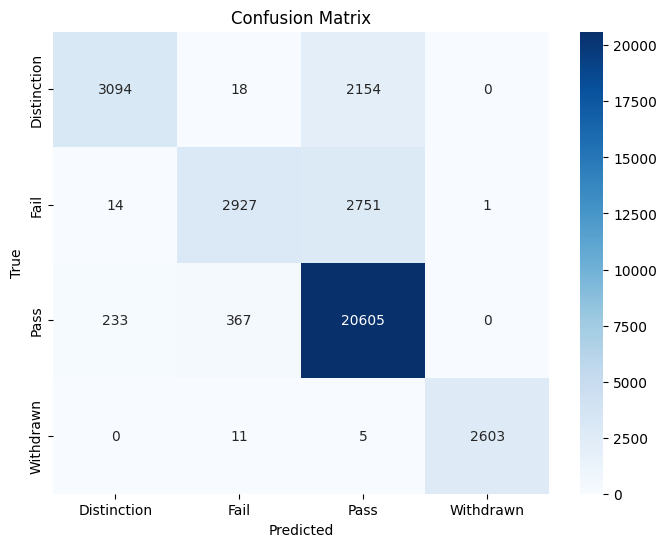

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

print("Training RandomForestClassifier...")

rf_classifier.fit(X_train, y_train)
print("Training complete.")

y_pred = rf_classifier.predict(X_test)

print("\nModel Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(map(str, le.classes_)),
            yticklabels=list(map(str, le.classes_)))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [9]:
sample_input = X_test.iloc[0:1]

predicted_encoded_label = rf_classifier.predict(sample_input)

predicted_final_result = le.inverse_transform(predicted_encoded_label)

print(f"Sample input (first row of X_test):\n{sample_input.T}")
print(f"\nPredicted encoded label: {predicted_encoded_label[0]}")
print(f"Predicted final result: {predicted_final_result[0]}")

true_encoded_label = y_test.iloc[0]
true_final_result = le.inverse_transform([true_encoded_label])
print(f"True encoded label: {true_encoded_label}")
print(f"True final result: {true_final_result[0]}")

Sample input (first row of X_test):
                                                  85757
id_assessment                                   25357.0
id_student                                     466714.0
date_submitted                                     74.0
is_banked                                           0.0
score                                              34.0
date                                               74.0
weight                                             17.5
num_of_prev_attempts                                2.0
studied_credits                                   120.0
date_registration                                 -62.0
date_unregistration                               166.0
total_clicks                                      165.0
time_to_submit                                      0.0
registration_days_before_start                     62.0
clicks_per_day_active                               2.2
assessment_late                                     0.0
assessment_e